In [1]:
import scanpy as sc
import seaborn as sns
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colormaps as cm
import numpy as np
from scipy.sparse import issparse
import pandas as pd
import os
import IPython.display
import matplotlib_inline.backend_inline
IPython.display.set_matplotlib_formats = matplotlib_inline.backend_inline.set_matplotlib_formats

In [ ]:
#sc.set_figure_params(dpi=600, frameon=False, format='png')

In [2]:
file = '/Users/rikac/Documents/mansfield_lab/spring_25/scrna_seq_analysis/bc3306_final_adata.h5ad'
adata = sc.read(file)

In [3]:
adata

AnnData object with n_obs × n_vars = 23299 × 18973
    obs: 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'doublet_scores', 'predicted_doublets', 'batch', 'leiden_0.01', 'leiden_0.025', 'leiden_0.05', 'leiden_0.1', 'leiden_0.15', 'leiden_0.2', 'leiden_0.4', 'ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DGEleiden0.01', 'DGEleiden0.025', 'DGEleiden0.05', 'DGEleiden0.1', 'DGEleiden0.15', 'DGEleiden0.2', 'DGEleiden0.4', 'ebf2+_sox9+_col2a1+_colors', 'ebf2+_sox9+_col2a1-_colors', 'hvg', 'leiden_0.01', 'leiden_0.01_colors', 'leiden_0.025', 'leiden_0.025_colors', 'leiden_0.05', 'leiden_0.05_

In [4]:
# original annotations
cluster_mapping = {
    "0": "Fibroblast progenitors",
    "1": "Fibroblast progenitors",
    "2": "Mitotic cells",
    "3": "Dermal fibroblasts",
    "4": "Neural progenitors",
    "5": "Smooth muscle",
    "6": "Fibroblast progenitors",
    "7": "Mast cells",
    "8": "Neural cells",
    "9": "Macrophages",
    "10": "Neural cells",
    "11": "Neural cells",
    "12": "Epidermis",
    "13": "Cartilage",
    "14": "Meninges",
    "15": "Neural cells",
    "16": "Neural cells",
    "17": "Endothelial cells",
    "18": "Schwann cells",
    "19": "Neural cells",
    "20": "Skeletal muscle",
    "21": "Neural cells",
    "22": "Red blood cells",
}

adata.obs["cell_type"] = adata.obs["leiden_0.4"].map(cluster_mapping)

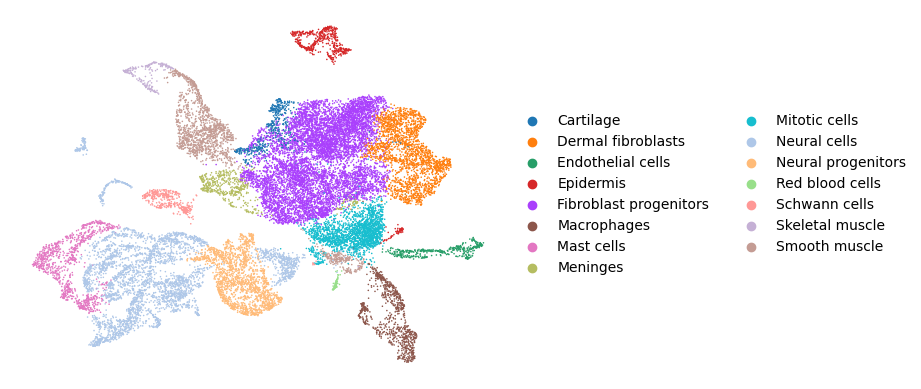

In [5]:
sc.pl.umap(adata, color='cell_type', frameon=False, title='')

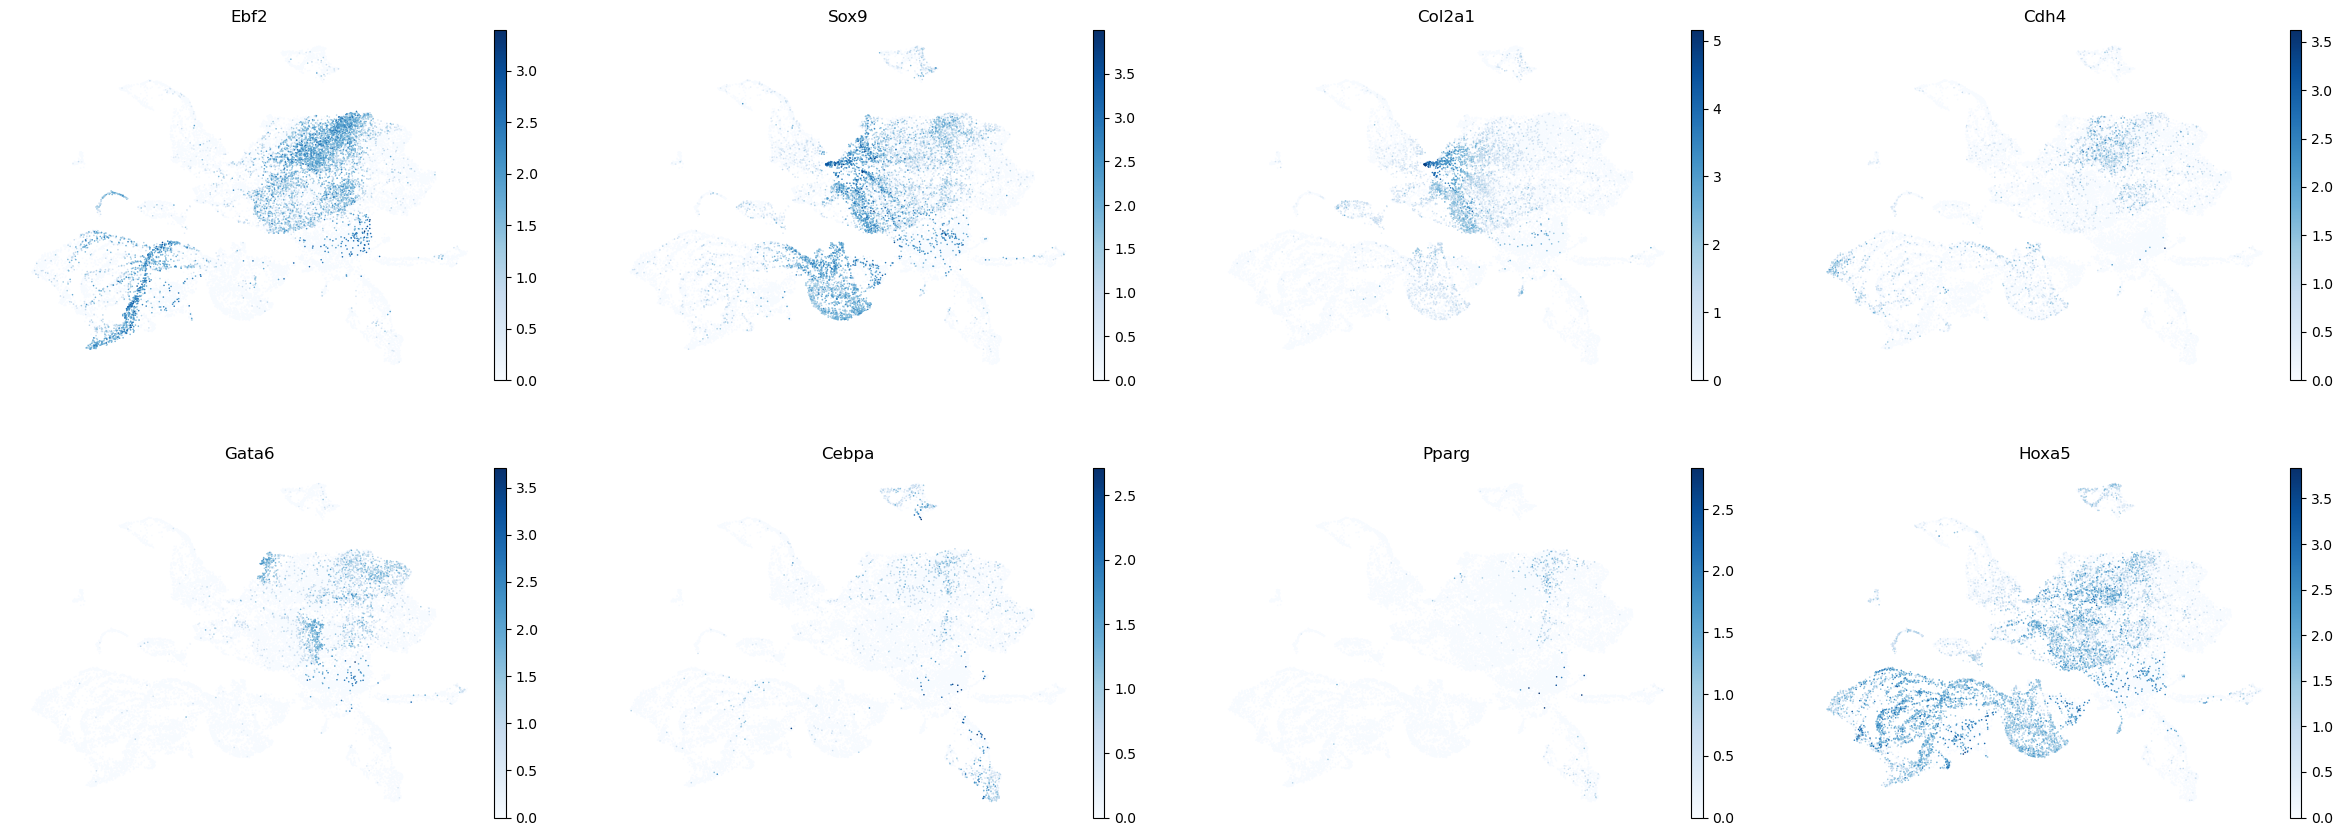

In [7]:
# bat genes expressions
bat_genes = ['Ebf2', 'Sox9', 'Col2a1', 'Cdh4', 'Gata6', 'Cebpa', 'Pparg', 'Hoxa5']
sc.pl.umap(adata, color=bat_genes, color_map='Blues', frameon=False)

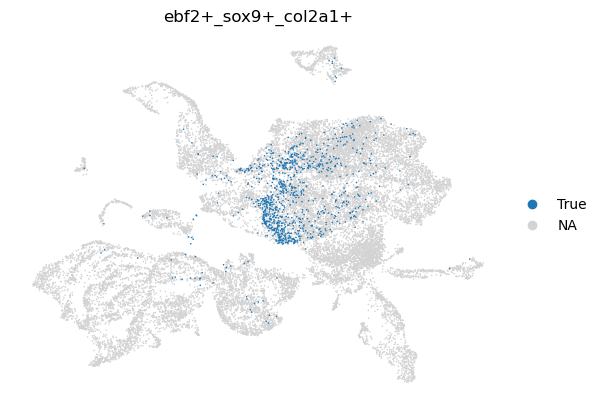

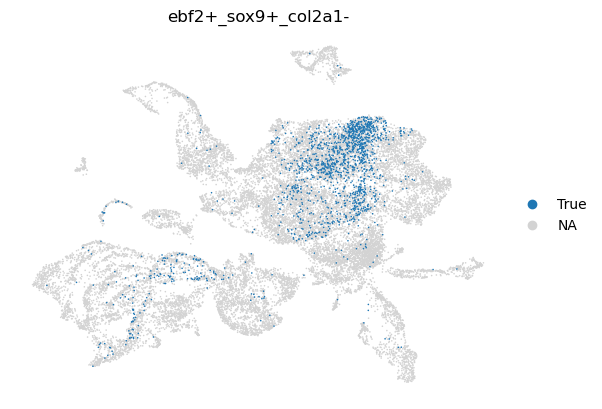

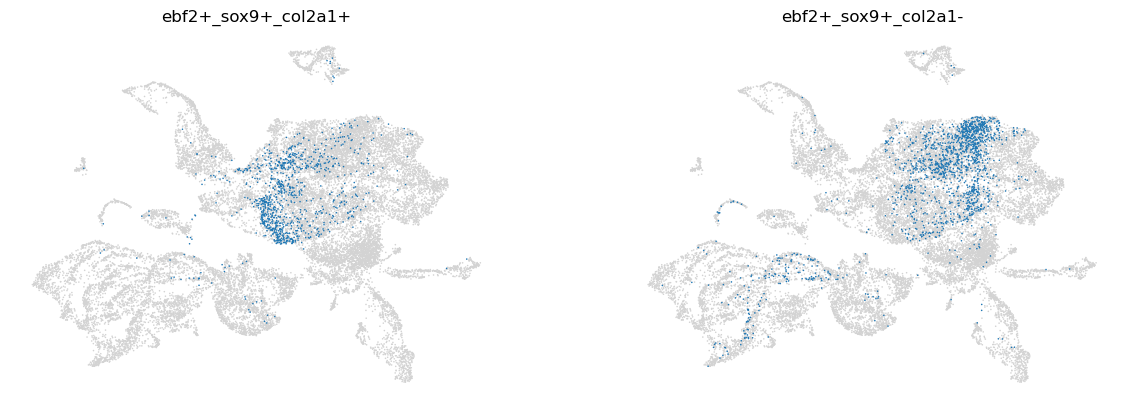

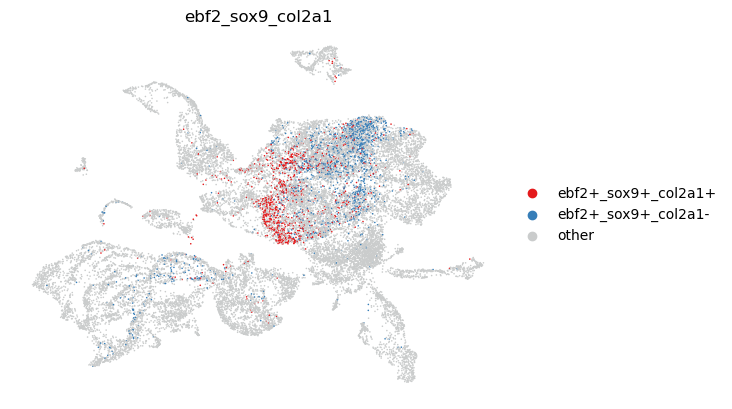

In [9]:
# UMAP of ebf2+/sox9+/col2a1- cells and UMAP of ebf2+/sox9+/col2a1+ cells

# ebf2+/sox9+/col2a1+ == 980 cells
coex = (adata.raw[:, '{}'.format('Ebf2')].X.todense() > 0) & (adata.raw[:, '{}'.format('Sox9')].X.todense() > 0) & (adata.raw[:, '{}'.format('Col2a1')].X.todense() > 0)
coex_list = [item for sublist in coex.tolist() for item in sublist]
adata.obs['ebf2+_sox9+_col2a1+'] = pd.Categorical(coex_list, categories=[True, False])
sc.pl.umap(adata, color='ebf2+_sox9+_col2a1+', groups=[True], frameon=False)

# ebf2+/sox9+/col2a1- == 1613 cells
coex1 = (adata.raw[:, '{}'.format('Ebf2')].X.todense() > 0) & (adata.raw[:, '{}'.format('Sox9')].X.todense() > 0) & (adata.raw[:, '{}'.format('Col2a1')].X.todense() == 0)
coex_list1 = [item for sublist in coex1.tolist() for item in sublist]
adata.obs['ebf2+_sox9+_col2a1-'] = pd.Categorical(coex_list1, categories=[True, False])
sc.pl.umap(adata, color='ebf2+_sox9+_col2a1-', groups=[True], frameon=False)

# the two figures on one page
sc.pl.umap(adata, color=['ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-'], groups=[True], legend_loc=None, frameon=False)

# plot the two conditions onto one figure with different colors
adata.obs['ebf2_sox9_col2a1'] = np.select(
    [coex_list, coex_list1],
    ['ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-'],
    default='other'
)
adata.obs['ebf2_sox9_col2a1'] = pd.Categorical(adata.obs['ebf2_sox9_col2a1'])
sc.pl.umap(adata, color='ebf2_sox9_col2a1', palette=['#E41A1C', '#377EB8', '#cacccc'], 
           frameon=False)

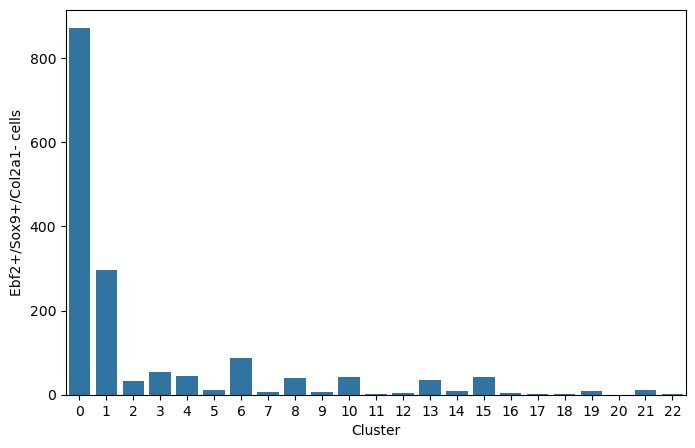

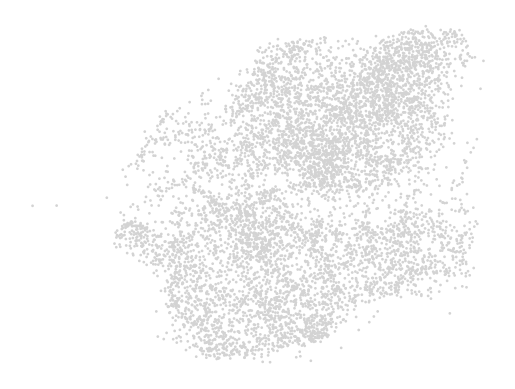

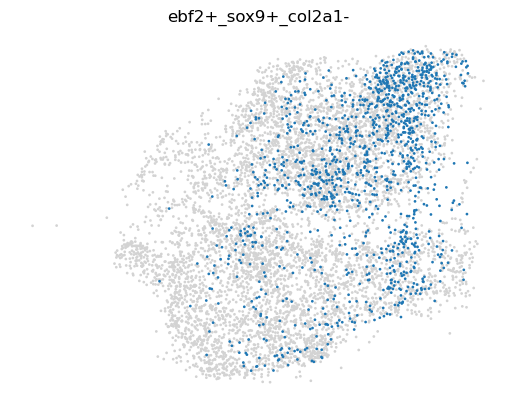

In [11]:
# chart of ebf2+/sox9+/col2a1- cells found in each cluster
cluster = adata.obs['leiden_0.4'].unique()
count_dict = {}
for i in cluster:
    counts = adata.obs[(adata.obs['ebf2+_sox9+_col2a1-'] == True) & (adata.obs['leiden_0.4'] == i)]
    count_dict[i] = len(counts)

df = pd.DataFrame(list(count_dict.items()), columns=['Cluster', 'Count'])
df['Cluster'] = pd.to_numeric(df['Cluster'], errors='coerce')
df = df.sort_values(by='Cluster').reset_index(drop=True)
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Cluster', y='Count')
plt.xlabel('Cluster')
plt.ylabel('Ebf2+/Sox9+/Col2a1- cells')
plt.show()

# umap fibroblast progenitors subset (0,1,6)
# subset cluster 0,1,6
FP_mask = adata.obs['leiden_0.4'].isin(['0', '1', '6'])
FP_adata_subset = adata[FP_mask, :]     # shape: 7819 × 18973
# plot just the 0,1,6 umap
sc.pl.umap(FP_adata_subset, frameon=False)
# plot ebf2+_sox9+_col2a1- cells on FP_adata_subet
sc.pl.umap(FP_adata_subset, color='ebf2+_sox9+_col2a1-', groups=[True], legend_loc=None, frameon=False)

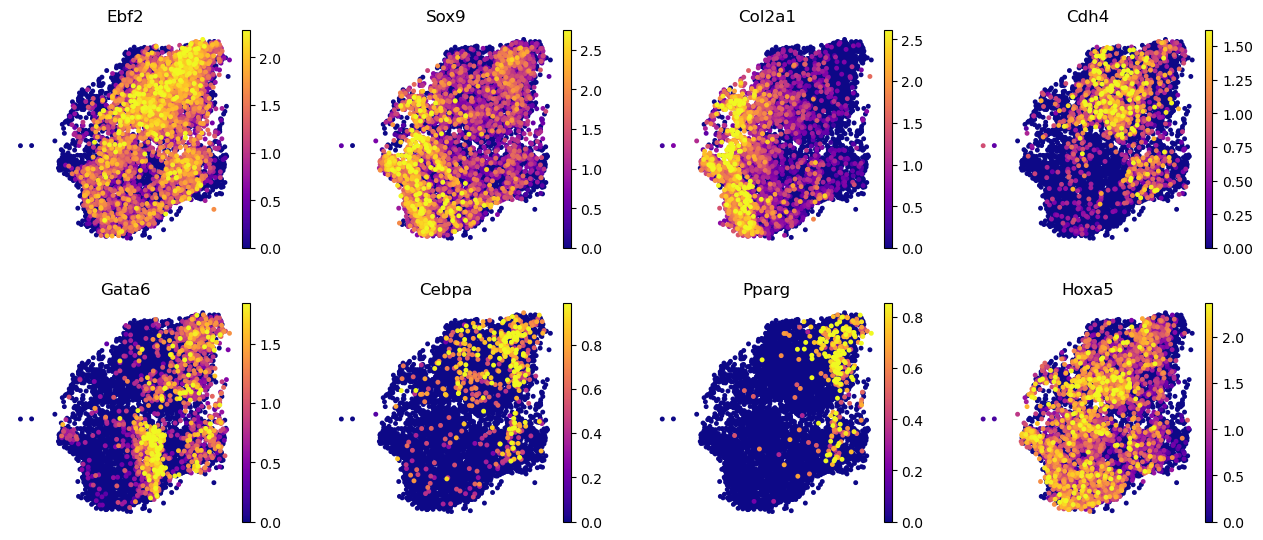

In [12]:
# expression plots of BAT markers in ebf2+_sox9+_col2a1- cells within FP clusters
# ver1 = bat markers in FP clusters
bat_genes1 = ['Ebf2', 'Sox9', 'Cdh4', 'Pparg', 'Hoxa5', 'Gata6', 'Cebpa']

with rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(FP_adata_subset, color=bat_genes, color_map = 'plasma', s=50, frameon=False, ncols=4, vmax="p99")

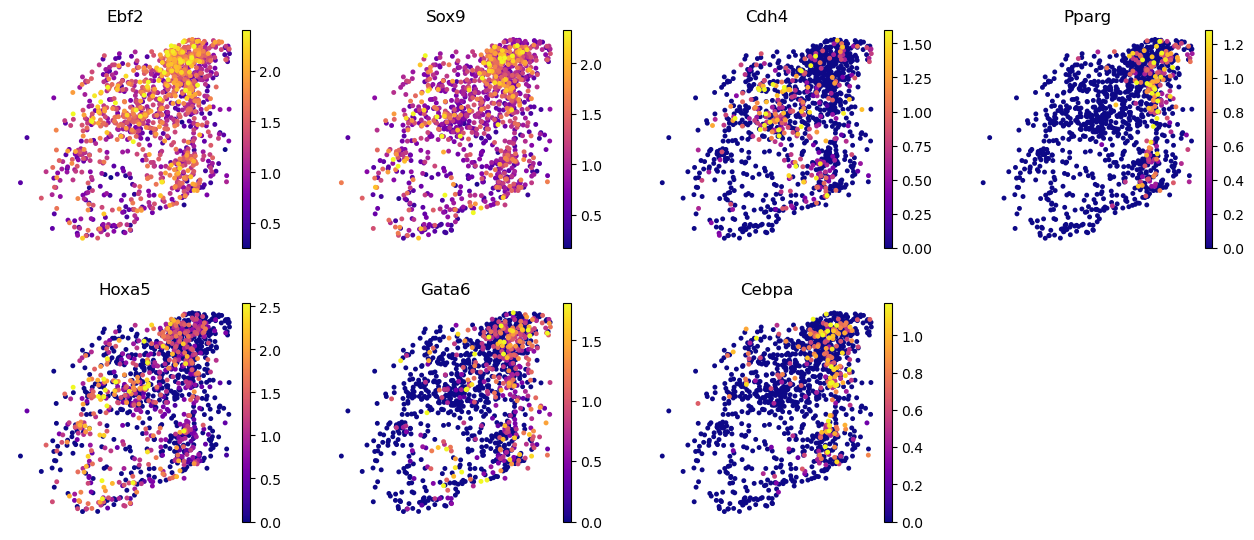

In [13]:
# ver2 = bat markers in ebf2+_sox9+_col2a1- cells within FP clusters
FP_subset_cond = FP_adata_subset[FP_adata_subset.obs['ebf2+_sox9+_col2a1-'] == True, :] # shape: 1255x18973
with rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(FP_subset_cond, color=bat_genes1, color_map = 'plasma', s=50, frameon=False, vmax="p99", ncols=4)

/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9745/3485356824.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  FP_subset_cond.obs['day'] = FP_subset_cond.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})
/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9745/3485356824.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  FP_subset_cond.obs['day'] = FP_subset_cond.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})
/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9745/3485356824.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be us

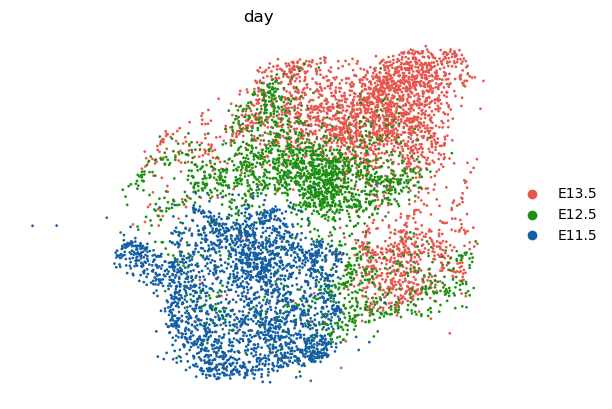

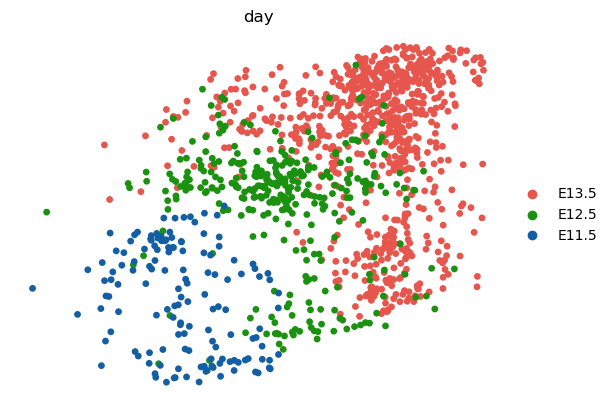

In [14]:
# label by sample of origin
# plot FP clusters and FP clusters+ebf2+_sox9+_col2a1- cells and label by samples
FP_subset_cond.obs['day'] = FP_subset_cond.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})
FP_adata_subset.obs['day'] = FP_adata_subset.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})

sc.pl.umap(FP_adata_subset, color='day', palette=['#e6564c', '#1b9110', '#145ea3'], frameon=False)
sc.pl.umap(FP_subset_cond, color='day', palette=['#e6564c', '#1b9110', '#145ea3'], frameon=False)

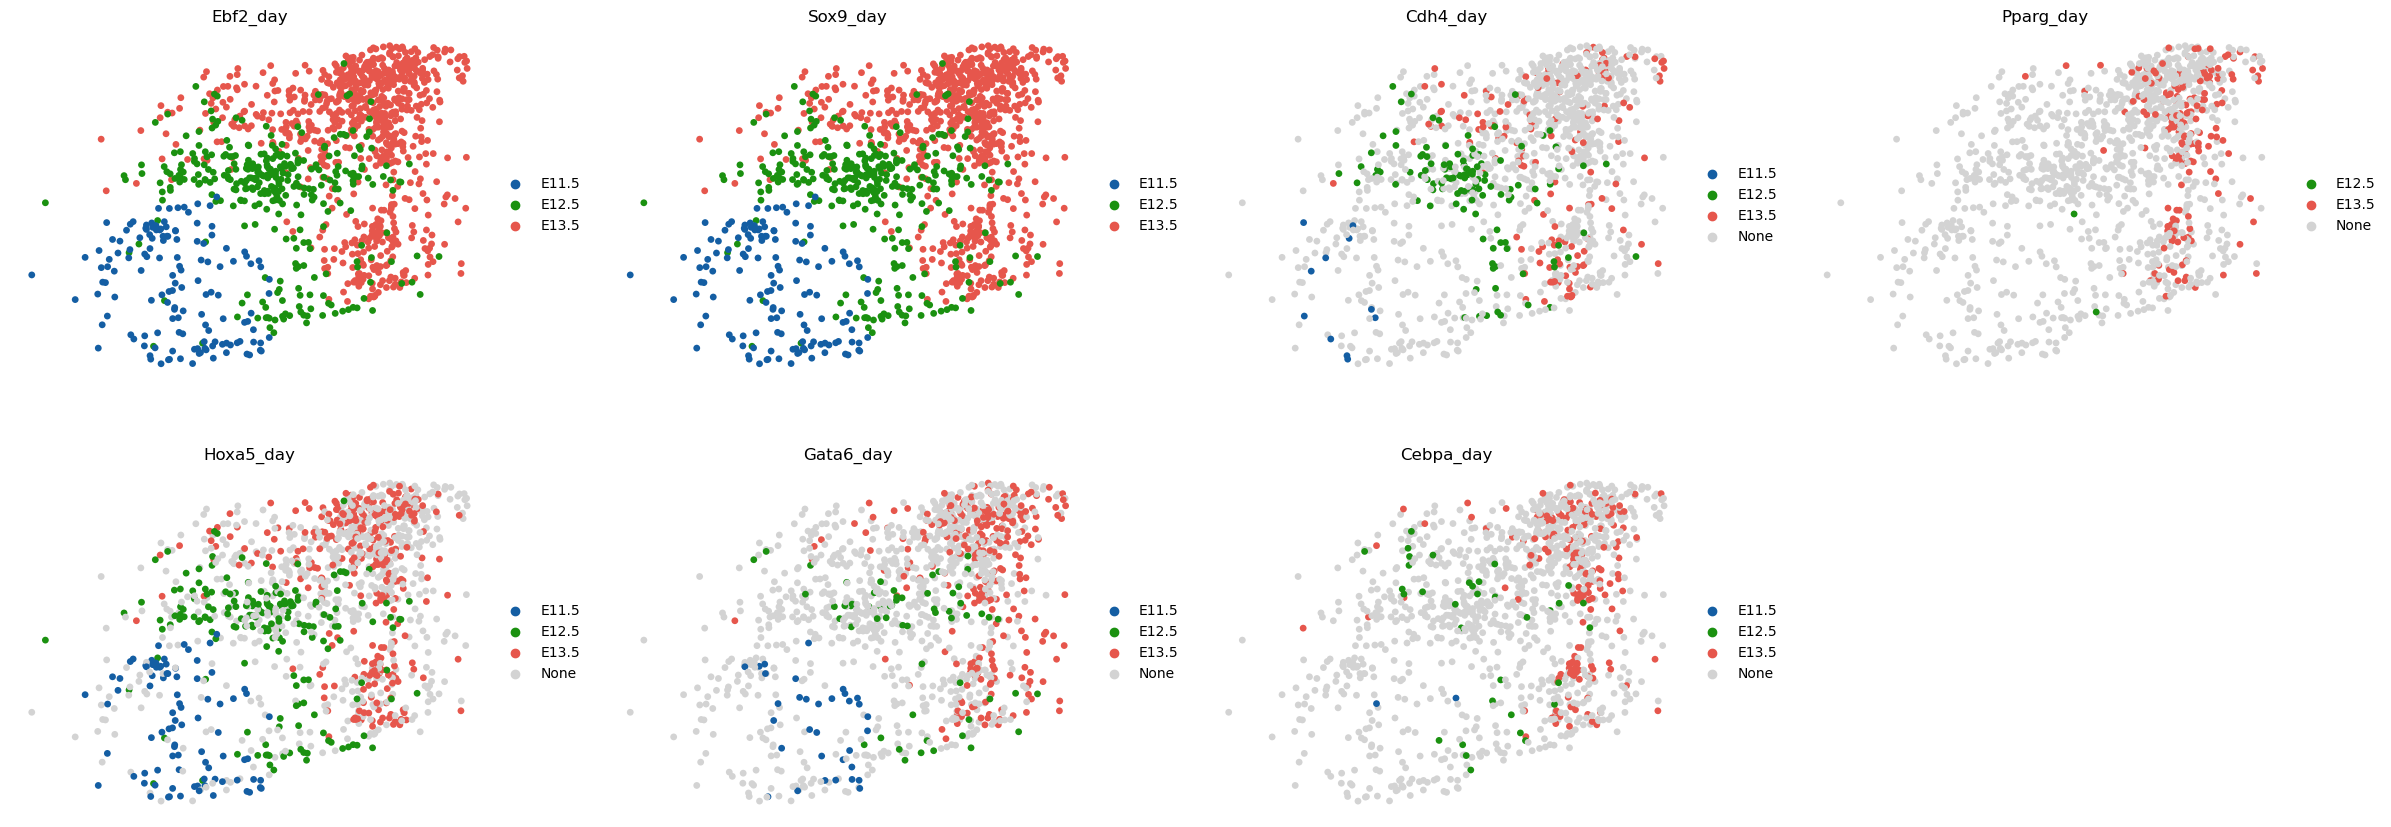

In [15]:
# plot bat genes expression categorized by time points
days = FP_subset_cond.obs['day']

for i in bat_genes1:
    bat_day = (FP_subset_cond.raw[:, '{}'.format(i)].X.todense() > 0)
    bat_day_list = [item for sublist in bat_day.tolist() for item in sublist]
    FP_subset_cond.obs[i] = pd.Categorical(bat_day_list, categories=[True, False])

    FP_subset_cond.obs[i+'_day'] = np.where(
        bat_day_list,
        FP_subset_cond.obs['day'],
        'None'
    )

custom_palette = {
    'E11.5': '#145ea3',
    'E12.5': '#1b9110', 
    'E13.5': '#e6564c',  
    'None': '#d3d3d3'  
}
bat_genes_day= ['Ebf2_day', 'Sox9_day', 'Cdh4_day', 'Pparg_day', 'Hoxa5_day', 'Gata6_day', 'Cebpa_day'] 
sc.pl.umap(FP_subset_cond, color=bat_genes_day, palette=custom_palette, frameon=False)

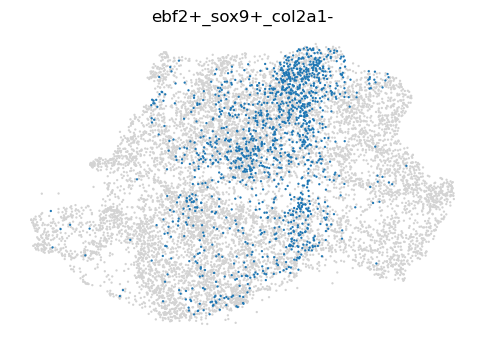

In [17]:
# subset pdgfra+ clusters
pdgfra_mask = adata.obs['leiden_0.4'].isin(['0', '1', '3', '6', '13', '14'])
pdgfra_adata_subset = adata[pdgfra_mask, :]     

# plot ebf2+_sox9+_col2a1- cells on FP_adata_subet
with rc_context({"figure.figsize": (6, 4)}):
    sc.pl.umap(pdgfra_adata_subset, color='ebf2+_sox9+_col2a1-', groups=[True], legend_loc=None, frameon=False)

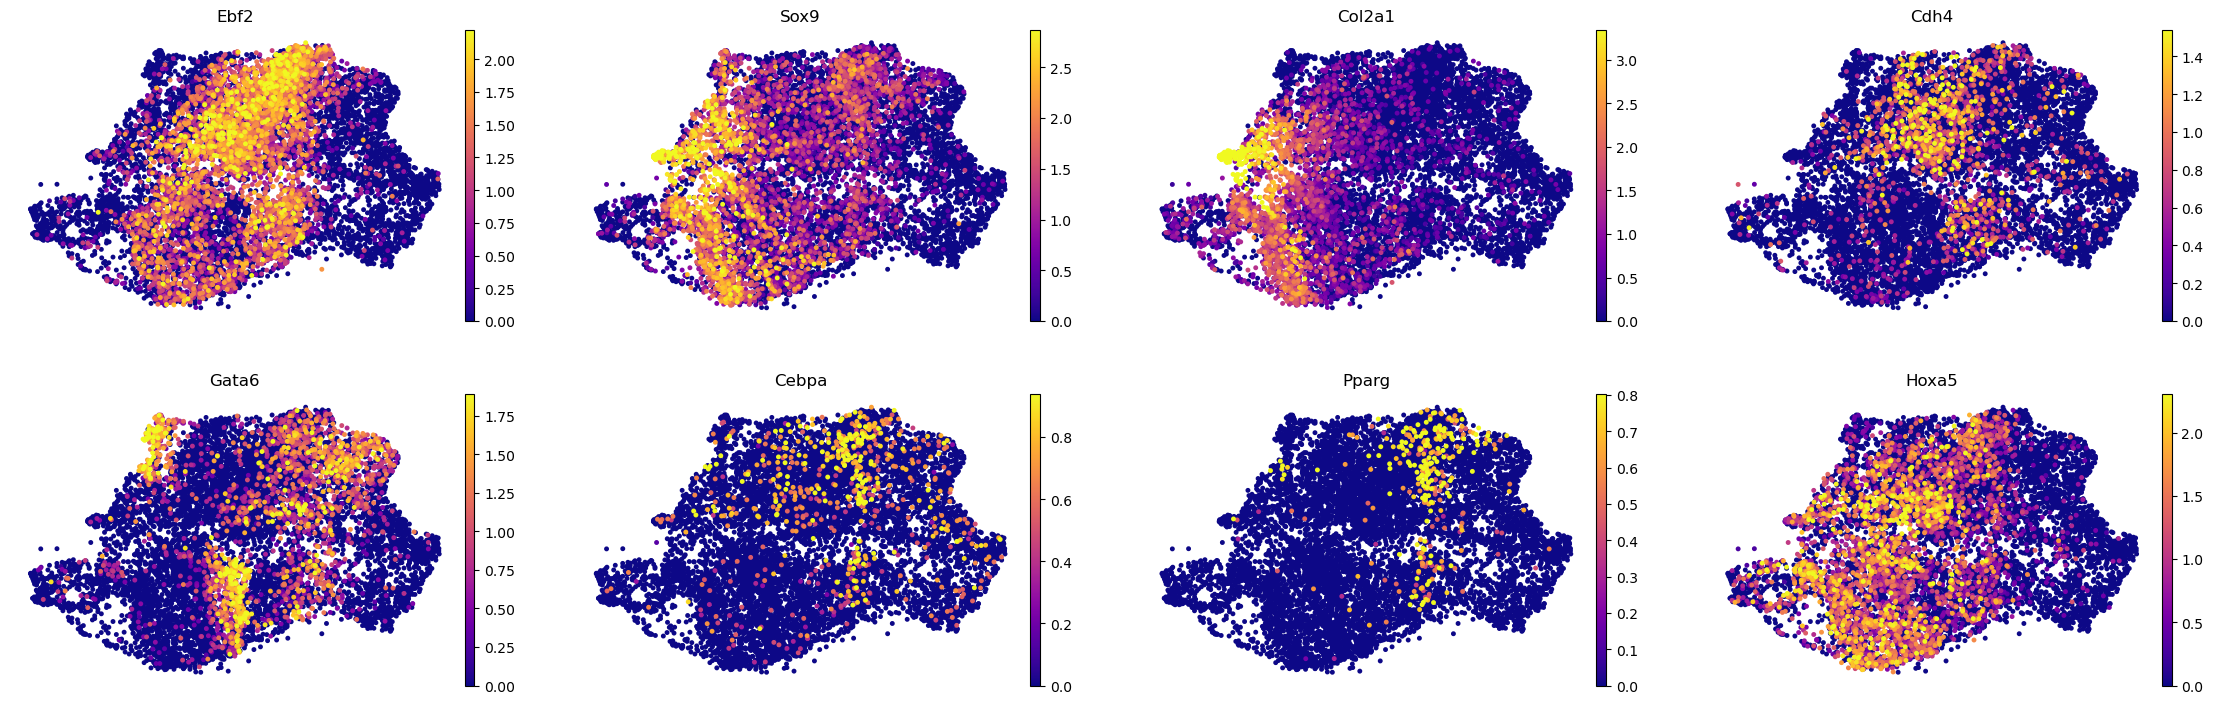

In [18]:
with rc_context({"figure.figsize": (6, 4)}):
    sc.pl.umap(pdgfra_adata_subset, color=bat_genes, color_map = 'plasma', s=50, frameon=False, ncols=4, vmax="p99")

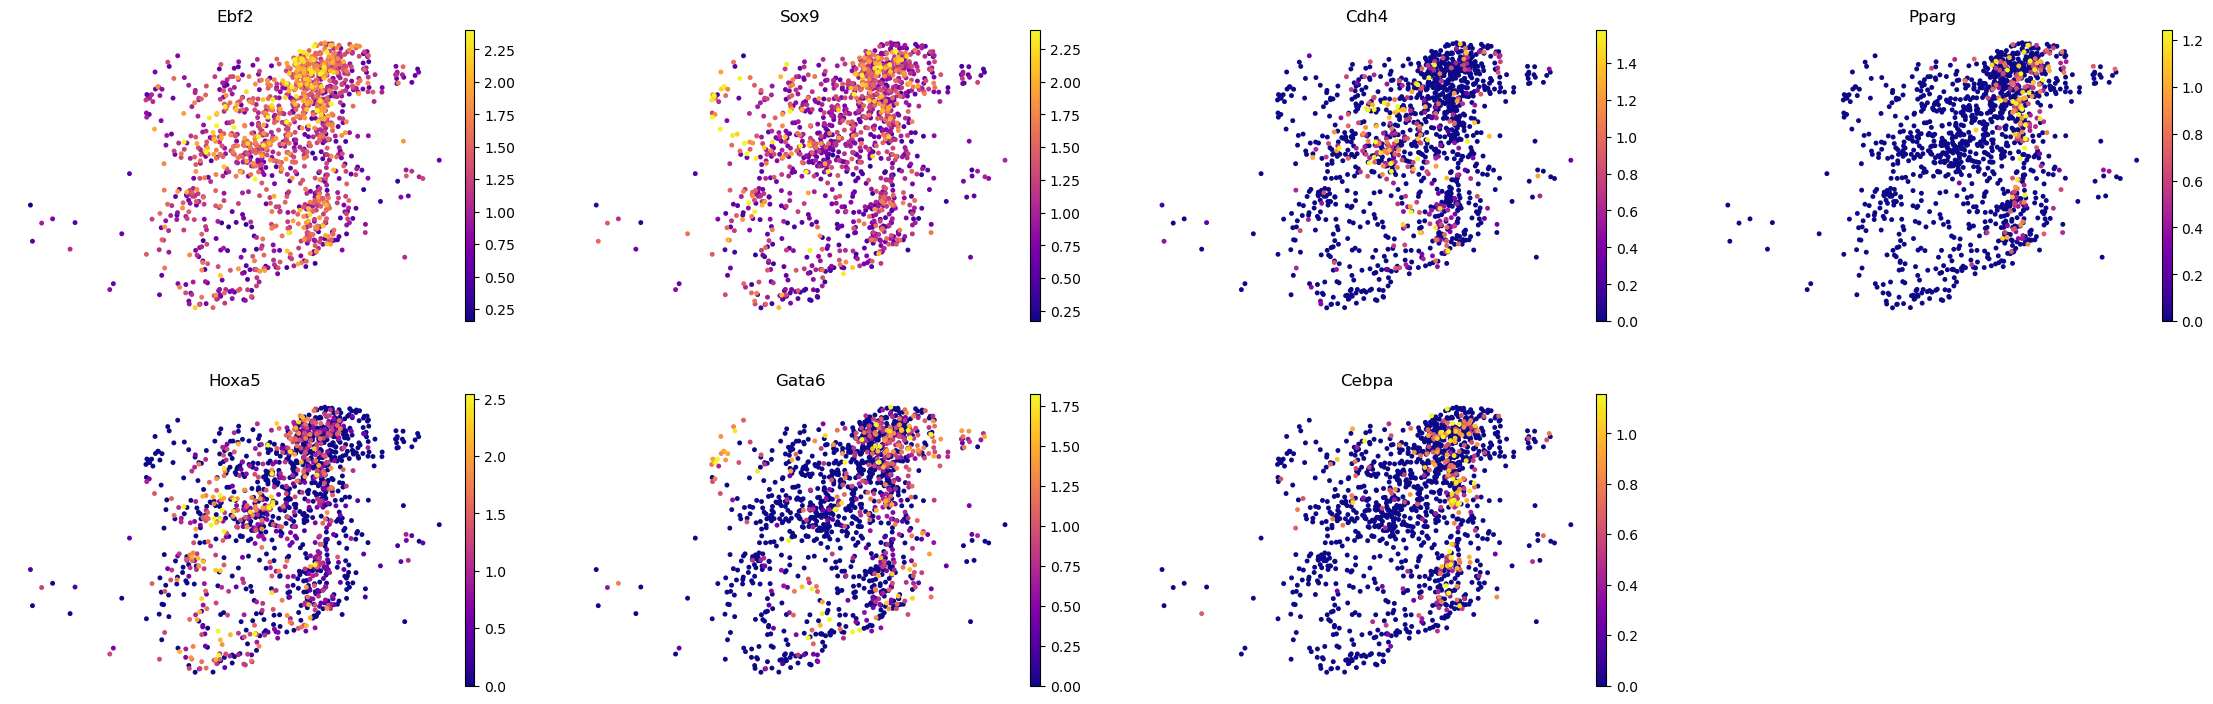

In [19]:
# ver2 = bat markers in ebf2+_sox9+_col2a1- cells within pdgfra+ clusters
pdgfra_subset_cond = pdgfra_adata_subset[pdgfra_adata_subset.obs['ebf2+_sox9+_col2a1-'] == True, :]

with rc_context({"figure.figsize": (6, 4)}):
    sc.pl.umap(pdgfra_subset_cond, color=bat_genes1, color_map = 'plasma', s=50, frameon=False, vmax="p99", ncols=4)

/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9745/853237371.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  pdgfra_adata_subset.obs['day'] = pdgfra_adata_subset.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})
/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9745/853237371.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  pdgfra_adata_subset.obs['day'] = pdgfra_adata_subset.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})


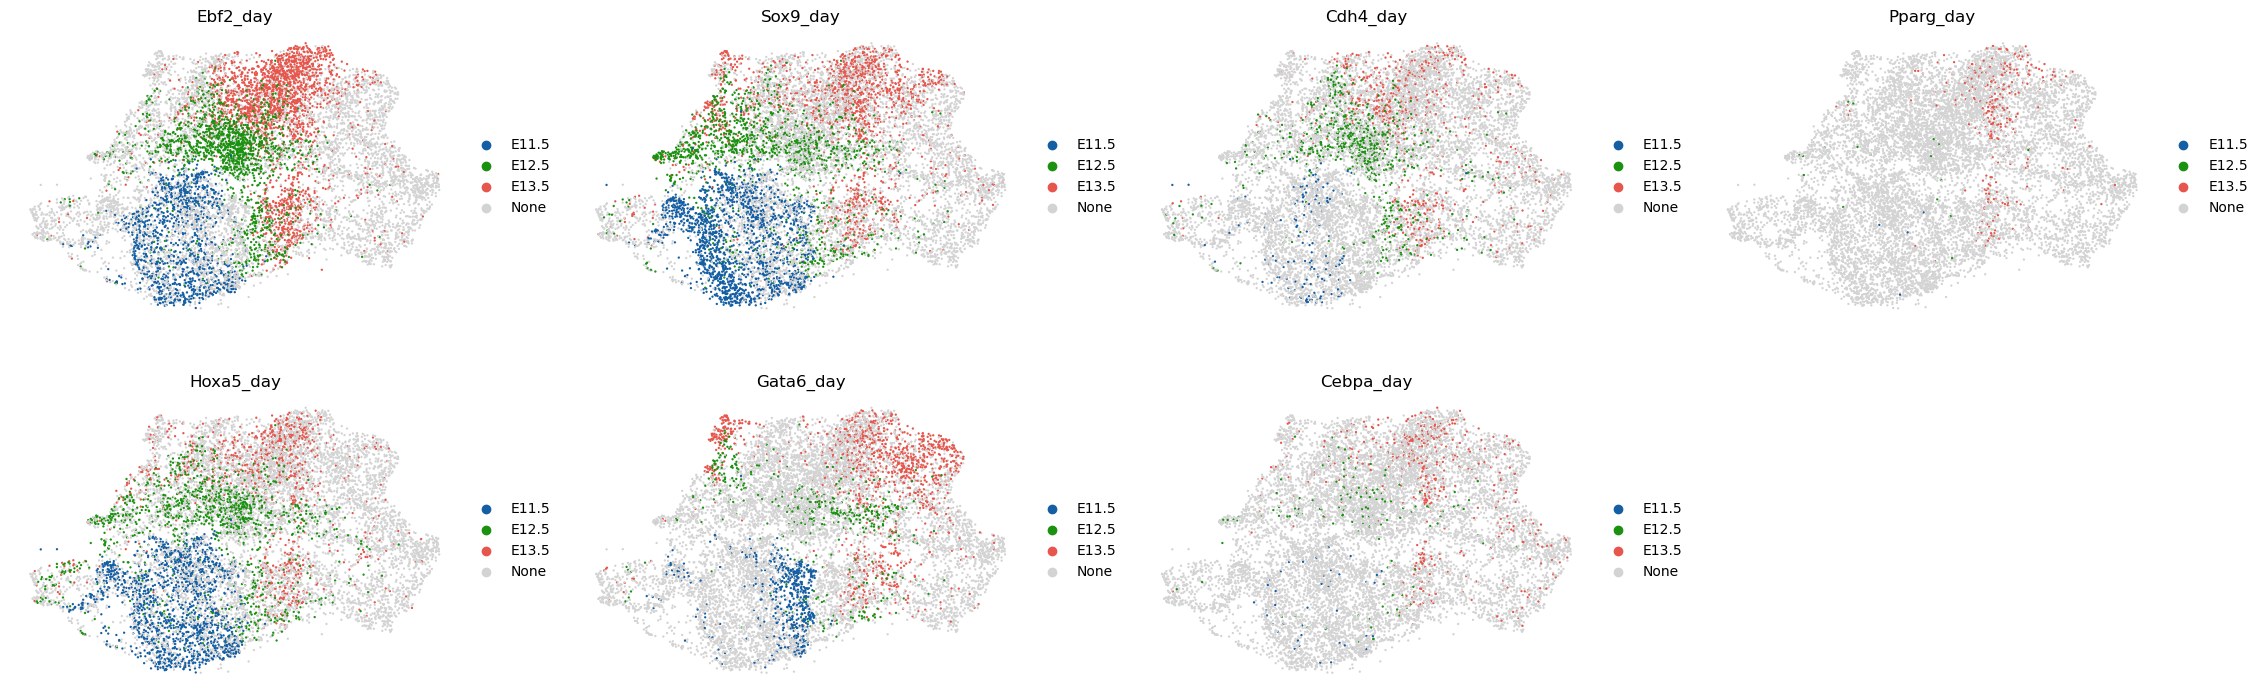

In [20]:
# plot bat genes expression categorized by time points (pdgfra)
pdgfra_adata_subset.obs['day'] = pdgfra_adata_subset.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})

days1 = pdgfra_adata_subset.obs['day']

for i in bat_genes1:
    bat_day1 = (pdgfra_adata_subset.raw[:, '{}'.format(i)].X.todense() > 0)
    bat_day_list1 = [item for sublist in bat_day1.tolist() for item in sublist]
    pdgfra_adata_subset.obs[i] = pd.Categorical(bat_day_list1, categories=[True, False])

    pdgfra_adata_subset.obs[i+'_day'] = np.where(
        bat_day_list1,
        pdgfra_adata_subset.obs['day'],
        'None'
    )

custom_palette = {
    'E11.5': '#145ea3',
    'E12.5': '#1b9110', 
    'E13.5': '#e6564c',  
    'None': '#d3d3d3'  
}
bat_genes_day1 = ['Ebf2_day', 'Sox9_day', 'Cdh4_day', 'Pparg_day', 'Hoxa5_day', 'Gata6_day', 'Cebpa_day'] 

with rc_context({"figure.figsize": (6, 4)}):
    sc.pl.umap(pdgfra_adata_subset, color=bat_genes_day1, palette=custom_palette, frameon=False)

/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9745/2942014242.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  pdgfra_subset_cond.obs['day'] = pdgfra_subset_cond.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})
/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9745/2942014242.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  pdgfra_subset_cond.obs['day'] = pdgfra_subset_cond.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})


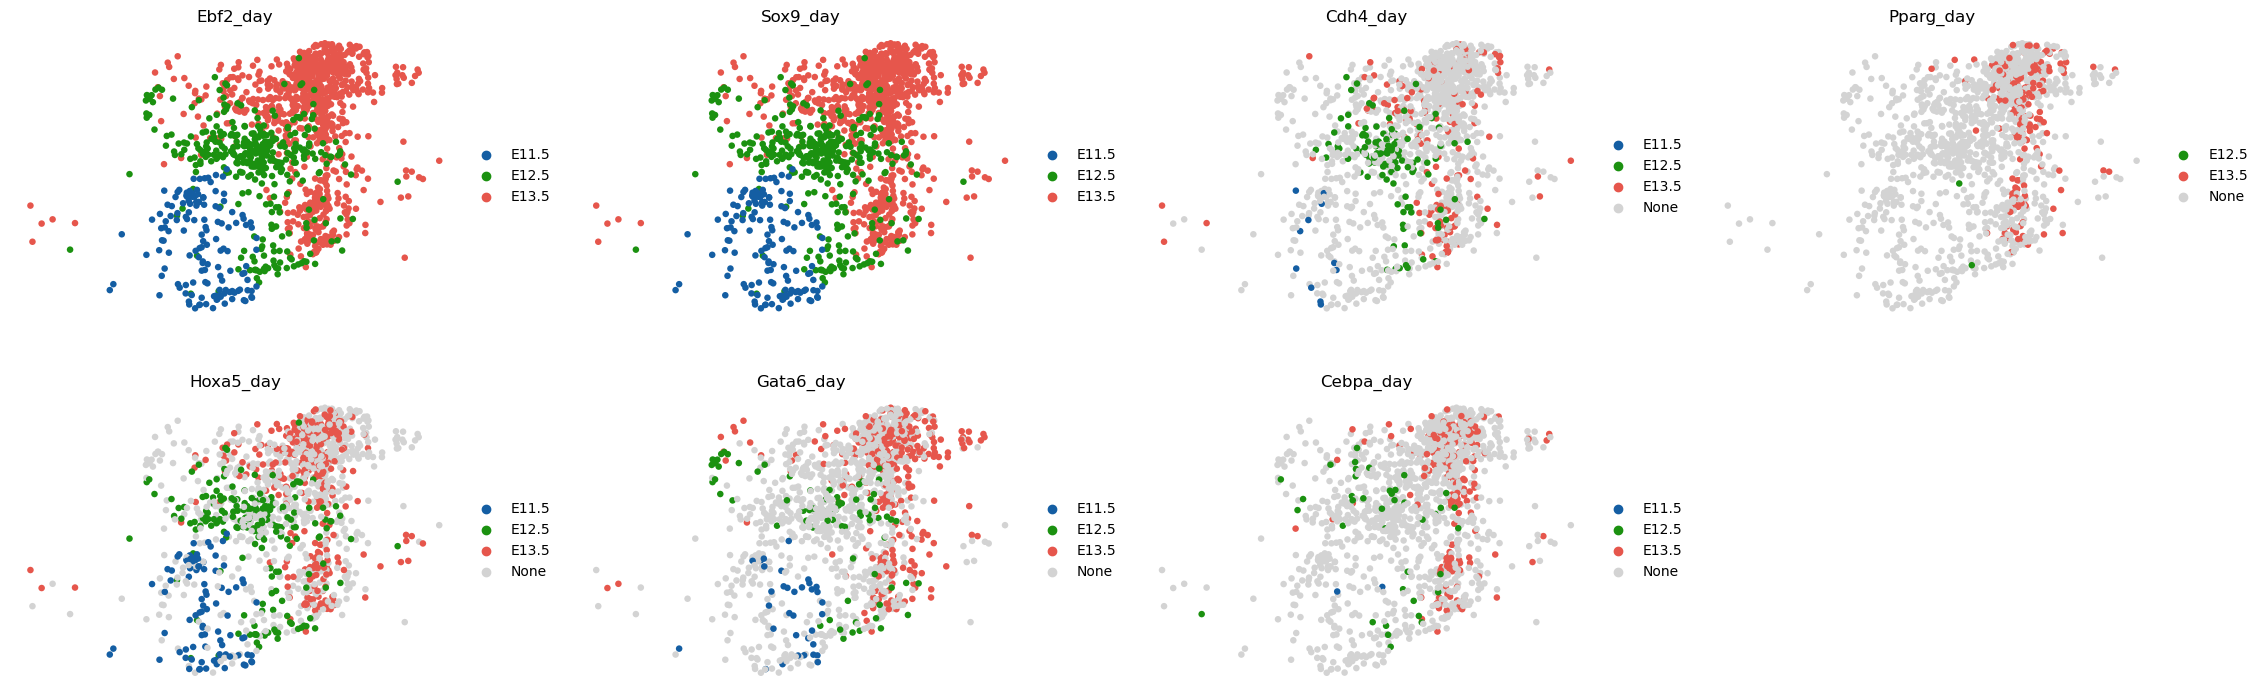

In [21]:
# plot bat genes expression categorized by time points (pdgfra and ebf2+_sox9+_col2a1- cells)
pdgfra_subset_cond.obs['day'] = pdgfra_subset_cond.obs['sample'].replace({'JJ003': 'E13.5', 'JJ004': 'E12.5', 'JJ005': 'E11.5'})

days1 = pdgfra_subset_cond.obs['day']

for i in bat_genes1:
    bat_day1 = (pdgfra_subset_cond.raw[:, '{}'.format(i)].X.todense() > 0)
    bat_day_list1 = [item for sublist in bat_day1.tolist() for item in sublist]
    pdgfra_subset_cond.obs[i] = pd.Categorical(bat_day_list1, categories=[True, False])

    pdgfra_subset_cond.obs[i+'_day'] = np.where(
        bat_day_list1,
        pdgfra_subset_cond.obs['day'],
        'None'
    )

custom_palette = {
    'E11.5': '#145ea3',
    'E12.5': '#1b9110', 
    'E13.5': '#e6564c',  
    'None': '#d3d3d3'  
}
bat_genes_day1 = ['Ebf2_day', 'Sox9_day', 'Cdh4_day', 'Pparg_day', 'Hoxa5_day', 'Gata6_day', 'Cebpa_day'] 

with rc_context({"figure.figsize": (6, 4)}):
    sc.pl.umap(pdgfra_subset_cond, color=bat_genes_day1, palette=custom_palette, frameon=False)